In [85]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import statsmodels.api as sm
import statsmodels.formula.api as smf


# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum

# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}

tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
]
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

## pre trend check

In [3]:
# path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
path_df=r"../data_processed\listings_tactics-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\2321625480.py:4: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 121)


In [ ]:
df_all[tactics_bio].isna().value_counts()
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)

In [25]:
print(df_all[['time', 'in_paris', "post"]].value_counts(dropna=False))
print(df_all.time.dtype)
df_pre=df_all[df_all['time']!=2406]
print(df_pre.shape)

time  in_paris  post
2406  1         1       62738
      0         1       49856
2312  0         0       43172
2306  0         0       42356
2312  1         0       35829
2306  1         0       32901
Name: count, dtype: int64
int64
(154258, 121)


In [26]:
## pre trend check!!!

# booking_rate_l90d
df=df_pre.copy()
formula= (" booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate + C(host_response_time)+ "
            "has_text + lang_fr + lang_en + text_length +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * C(time)"
)
model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors
summary=model.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     1962.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:15:39   Log-Likelihood:                 36584.
No. Observations:              154258   AIC:                        -7.312e+04
Df Residuals:                  154232   BIC:                        -7.286e+04
Df Model:                          25                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

# tactic~

In [50]:
df_all["time"]=df["time"].astype(str)
df_all['trend'] = df_all['time'].map({'2306':0, "2312":1, '2406':2})#***
print(df_all[['in_paris',"time","trend","post"]].value_counts(dropna=False))

in_paris  time  trend  post
1         2406  2      1       62738
0         2406  2      1       49856
          2312  1      0       43172
          2306  0      0       42356
1         2312  1      0       35829
          2306  0      0       32901
Name: count, dtype: int64



## + trend: "C(time) + in_paris*trend + in_paris * post"


In [ ]:

# ✔ 1. C(time) # 控制所有城市共同的时间变化（宏观趋势）
# ✔ 2. in_paris * trend # 允许 Paris 和 London 有不同的趋势（解决你发现的不平行问题）
# ✔ 3. in_paris * post # 👉 在控制趋势差异之后，识别 JO 的“额外冲击”

# 在控制了城市固定差异、时间效应以及城市特定趋势（city-specific trends）之后，
# in_paris × post 捕捉了 2024年巴黎奥运会 对 Paris 相对于 London 的“额外变化”（differential change）

# 优点： 清晰、好解释（有一个系数）
# 缺点： 强结构假设的 DiD（parametric DiD）：
# pre-trend 是线性的
# treatment effect 是“一个跳跃 + 一个趋势修正”


In [44]:

def run_model_tactic(df, y):
    formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            
            # "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
            # "C(host_picture_type) +"
            # "pic_no_person + pic_pro_style + pic_life_style +"
            # " is_smiling + "
            # "C(age_class) + C(gender) +"
            "C(time) + in_paris*trend + in_paris * post"
    )
    model_tactic=smf.ols(formula, data=df).fit()
    # summary=model_tactic.summary()
    # print(summary)
    return model_tactic


results=[]
for var in tactics_bio:
    print(var)
    model=run_model_tactic(df, var)
    term="in_paris:post"
    coef = model.params[term]
    se = model.bse[term]
    pval = model.pvalues[term]
    
    results.append({
        "variable": var,
        "coef": coef,
        "se": se,
        "pval": pval,
        "sig": p_to_sig(pval),
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se
    })
results_df = pd.DataFrame(results)


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


In [45]:
results_df

,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.009624,0.010803,0.373031,,-0.030798,0.011551
1,authenticité,-0.015611,0.011191,0.163017,,-0.037545,0.006323
2,sociabilité,-0.009865,0.011565,0.393671,,-0.032532,0.012803
3,auto_promotion,0.042751,0.010544,0.000050,***,0.022086,0.063417
4,exemplarité,0.044509,0.011202,0.000071,***,0.022553,0.066464


<Figure size 640x480 with 0 Axes>

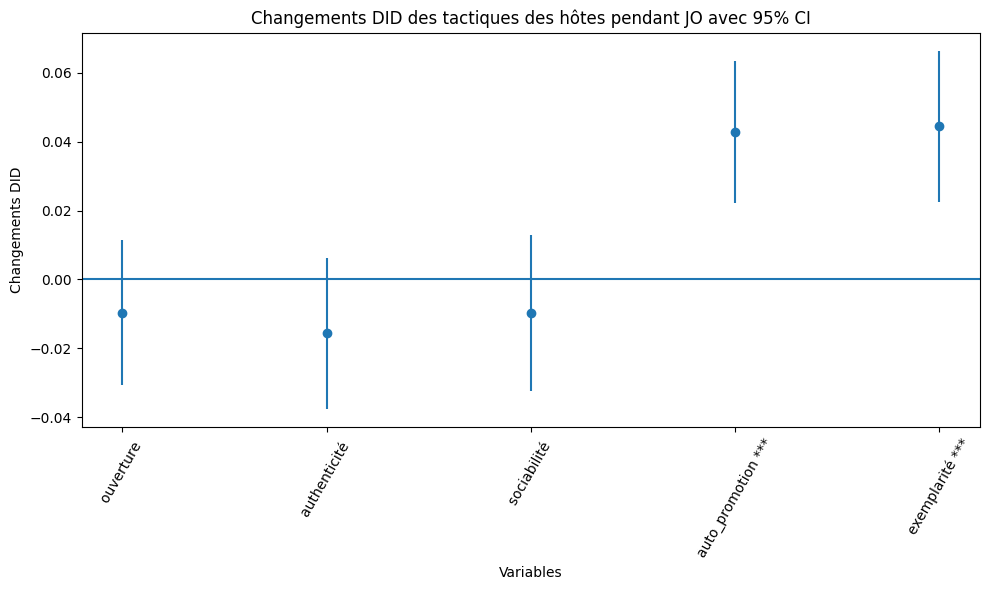

In [46]:
# did effect
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['sig']

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("Changements DID")
plt.title("Changements DID des tactiques des hôtes pendant JO avec 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## event study :C(time) + in_paris * C(time)


In [ ]:
## event study :C(time) + in_paris * C(time)
# 不假设差异趋势是线性的
# # 弱假设 / 非参数 DiD（event study）：[更加稳健]
# 每个时间点可以自由变化,不强制趋势形状
##==允许：2312 下跌，2406 反弹，不规则变化

# C(time)固定时间变化（季节，整体增长）
# 交互项：paris(相对于london)[在每个时间点]的额外变化

# | 时间   | Paris 相对 London 的差异 |
# | ---- | ------------------- |
# | 2306 | baseline（被省略）     |
# | 2312 | β₁（pre-trend）       |
# | 2406 | β₂（JO + trend）      |
# JO effect ≈ β_2406 - β_2312 (24差异减去稳定差异==jo额外差异)

# 线性组合计算β_2406 - β_2312 = 0 ?


##结果差异，不仅因为数据不稳定，还有模型假设的差异

In [119]:
# ouverture ~ controls + tactics + C(time) + in_paris * C(time)

def run_model_tactic_2(df, y):
    formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)"
    )
    model_tactic=smf.ols(formula, data=df).fit()
    return model_tactic

model=run_model_tactic_2(df, y="authenticité")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           authenticité   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     2007.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:06:55   Log-Likelihood:            -2.6399e+05
No. Observations:              266852   AIC:                         5.280e+05
Df Residuals:                  266824   BIC:                         5.283e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [ ]:
# event study 图：Paris 相对于 London，在不同时间点的“动态差异路径”

import pandas as pd
import matplotlib.pyplot as plt

def get_event_study_data(model, var):
    params = model.params
    bse = model.bse
    
    # 提取 interaction terms
    df = pd.DataFrame({
        "coef": params,
        "se": bse
    }).reset_index()

    df.columns = ["variable", "coef", "se"]

    # 只保留 in_paris × time
    df = df[df["variable"].str.contains("in_paris:C\\(time\\)")]
    # display(df)
    
    # 提取时间点
    df["time"] = df["variable"].str.extract(r"T\.(\d+)")

    # 排序
    df = df.sort_values("time")

    # 置信区间
    df["ci_low"] = df["coef"] - 1.96 * df["se"]
    df["ci_high"] = df["coef"] + 1.96 * df["se"]

    # baseline（2306 = 0）
    baseline = pd.DataFrame({
        "time": ["2306"],
        "coef": [0],
        "ci_low": [0],
        "ci_high": [0]
    })

    df = pd.concat([baseline, df], ignore_index=True)

    # 转 numeric
    df["time"] = pd.to_numeric(df["time"])
    df = df.sort_values("time")
    df['time']=df['time'].astype(str)
    # display(df)
    df['variable']=var
        
    return df


In [ ]:
df=df_all.copy()
df_list=[]
for i, y in enumerate(tactics_bio):
    print (i, y)
    model=run_model_tactic_2(df, y)
    res =  get_event_study_data(model, y)
    df_list.append(res)
    # if i >1:
    #     break  
results=pd.concat(df_list, axis=0)
results

0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


,time,coef,ci_low,ci_high,variable,se
0,2306,0.000000,0.000000,0.000000,ouverture,NaN
1,2312,0.005668,-0.006977,0.018313,ouverture,0.006452
2,2406,0.001713,-0.010052,0.013477,ouverture,0.006002
0,2306,0.000000,0.000000,0.000000,authenticité,NaN
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218
0,2306,0.000000,0.000000,0.000000,sociabilité,NaN
1,2312,0.022324,0.008787,0.035861,sociabilité,0.006906
2,2406,0.034783,0.022189,0.047377,sociabilité,0.006426
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_event_study(df, title="Event Study - Tactics Comparison"):
    
    plt.figure(figsize=(8, 6))

    strategies = df["variable"].unique()

    for var in strategies:
        sub = df[df["variable"] == var].copy()

        # 确保排序
        sub = sub.sort_values("time")

        # baseline处理（2306 = 0）
        if (sub["time"] == '2306').any():
            sub.loc[sub["time"] == '2306', "coef"] = 0
            sub.loc[sub["time"] == '2306', "ci_low"] = 0
            sub.loc[sub["time"] == '2306', "ci_high"] = 0

        # 画线
        plt.plot(sub["time"], sub["coef"], marker="o", label=var)

        # # 置信区间
        # plt.fill_between(
        #     sub["time"],
        #     sub["ci_low"],
        #     sub["ci_high"],
        #     alpha=0.15
        # )

    # 参考线
    plt.axhline(0, linestyle="--", color="black", linewidth=1)

    # # JO标记（2406）
    # plt.axvline('2406', linestyle="--", color="black", alpha=0.6)
    # plt.text('2406', plt.ylim()[1]*0.8,"JO", color="black")

    # 美化
    plt.xlabel("Time")
    plt.ylabel("Paris - London Effect")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.show()
plot_event_study(df=results, title="Event Study - Tactics Comparison")

## 每个时间点paris相对于london，额外变化的量==time:in_paris

## 2406:trend+jo的情况下，auth, soc,ouv增长减少，auto, exe增加

TypeError: list indices must be integers or slices, not str

<Figure size 800x600 with 0 Axes>

In [120]:
test = model.t_test("in_paris:C(time)[T.2406] - in_paris:C(time)[T.2312] = 0")
print(test)
coef = float(test.effect)
print(coef)


                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0140      0.006      2.300      0.021       0.002       0.026
0.014043224391017566


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\1756918883.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coef = float(test.effect)


In [63]:
import pandas as pd

def extract_diff_result(model, y_name):
    # 做线性检验（差分）
    test = model.t_test("in_paris:C(time)[T.2406] - in_paris:C(time)[T.2312] = 0")
    
    # 提取数值
    coef = float(test.effect)# coef
    se = float(test.sd)# 
    tval = float(test.tvalue)
    pval = float(test.pvalue)
    
    ci_low, ci_high = test.conf_int()[0]

    # 整理成 DataFrame
    df=pd.DataFrame({
        # "variable": ["JO_effect"],
        "variable": [y_name],
        "coef": [coef],
        "se": [se],
        "pval": [pval],
        "sig": [p_to_sig(pval)],
        "ci_low": [ci_low],
        "ci_high": [ci_high],
    })
    return df


In [116]:
results=[]
for y in tactics_bio:
    print (y)
    model=run_model_tactic_2(df, y)
    res=extract_diff_result(model=model, y_name=y)
    results.append(res)
results_df=pd.concat(results, axis=0)
display(results_df)


ouverture


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coef = float(test.effect)# coef
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test.sd)#
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tval = float(test.tvalue)


authenticité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coef = float(test.effect)# coef
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test.sd)#
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tval = float(test.tvalue)


sociabilité


...

auto_promotion


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coef = float(test.effect)# coef
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test.sd)#
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tval = float(test.tvalue)


exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coef = float(test.effect)# coef
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test.sd)#
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28424\144915755.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tval = float(test.tvalue)


,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598
0,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011
0,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827
0,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839
0,exemplarité,0.024492,0.006112,6.149051e-05,***,0.012512,0.036471


<Figure size 640x480 with 0 Axes>

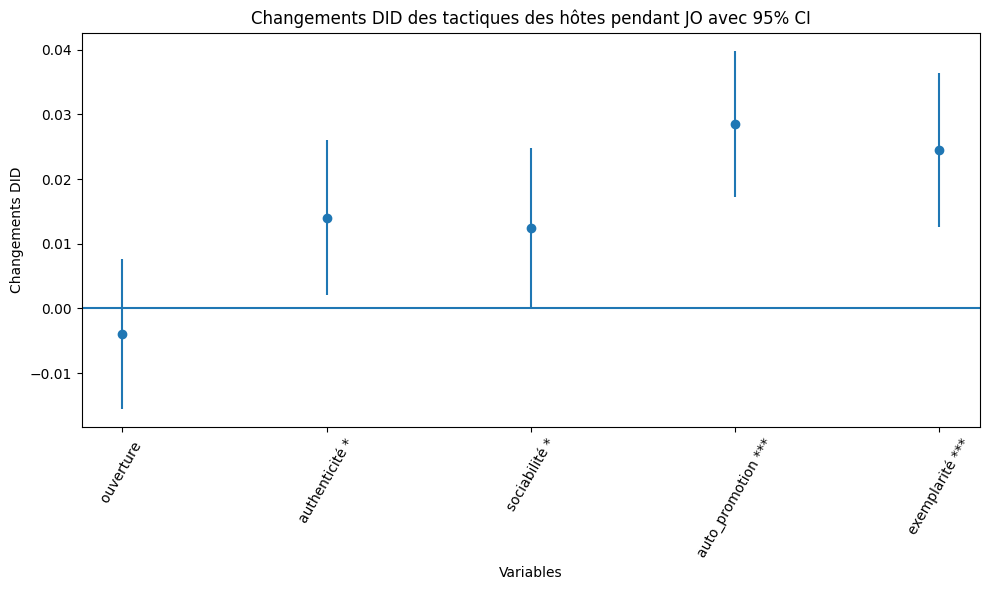

In [117]:
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['sig']

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("Changements DID")
plt.title("Changements DID des tactiques des hôtes pendant JO avec 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

# booking_rate~

In [39]:
# df_2324=df_all[df_all['time']!=2312]
# print(df_2324[['in_paris','time']].value_counts(dropna=False))

df=df_all.copy()

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        # "C(host_picture_type) +"
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"
        "C(time) + in_paris*trend + in_paris * post"
)

model_basic=smf.ols(formula, data=df).fit()
summary=model_basic.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     5530.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:30:09   Log-Likelihood:                 88253.
No. Observations:              266852   AIC:                        -1.764e+05
Df Residuals:                  266819   BIC:                        -1.761e+05
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [33]:
df=df_all.copy()

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "

        # "C(host_picture_type) +"
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"
        "in_paris*trend + C(time) +"
        "in_paris * post *(ouverture + authenticité + sociabilité + auto_promotion + exemplarité)"

)

model_interaction=smf.ols(formula, data=df).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     3772.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:25:04   Log-Likelihood:                 88352.
No. Observations:              266852   AIC:                        -1.766e+05
Df Residuals:                  266804   BIC:                        -1.761e+05
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------